In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import cv2
import numpy as np

def extract_features(image_path, bins=8):
    img = cv2.imread(image_path) # channels in order BGR
    img = cv2.resize(img, (170, 170))
    features = {}
    
    # Color features (mean, std, median)

    for i, color in enumerate(['blue', 'green', 'red']):
        channel = img[:,:,i]
        
        features[f'{color}_mean'] = np.mean(channel)
        features[f'{color}_std'] = np.std(channel)
        features[f'{color}_median'] = np.median(channel)
        



        # Calculate histogram for each color channel , 
        hist = cv2.calcHist([channel], [0], None, [bins], [0, 256])  
         #bins is using 8 as value which is generally the default
         # None means that no mask are needed, we take all the pixels! 
         #

        # hist = hist / hist.sum()  # Normalize the histogram, so the sum is 1 
        
        # Add histogram bins to features
        for j in range(bins):
            features[f'{color}_hist_{j}'] = hist[j][0]
    
    return features

In [3]:
import matplotlib.pyplot as plt

# Generate a synthetic blue image (for testing)
test_image = np.zeros((100, 100, 3), dtype=np.uint8)
test_image[:, :, 0] = 255  # Set Blue channel to max
cv2.imwrite("test_blue.jpg", test_image)

# Extract features
features = extract_features("test_blue.jpg")
print(features["blue_mean"])  # Should print ~255.0
print(features["red_mean"])   # Should print ~0.0

254.0
0.0


In [4]:
img= cv2.imread('Non-Sperm (2).bmp') 
    

[ WARN:0@30.465] global loadsave.cpp:268 findDecoder imread_('Non-Sperm (2).bmp'): can't open/read file: check file path/integrity


In [5]:
from pathlib import Path

p = Path("data")
# Cuenta todos los ficheros (de cualquier nivel y con cualquier extensión)
count = len(list(p.rglob("*.*")))
print(f"Total de archivos en '{p}': {count}")


Total de archivos en 'data': 3000


In [8]:
img = cv2.imread('Abnormal_Sperm (18) copy.bmp')

[ WARN:0@43.705] global loadsave.cpp:268 findDecoder imread_('Abnormal_Sperm (18) copy.bmp'): can't open/read file: check file path/integrity


In [10]:
img.shape

AttributeError: 'NoneType' object has no attribute 'shape'

In [11]:
import cv2
import matplotlib.pyplot as plt

def calc_hist(sample_image, bins=8, save_path = None ):
     
    testing = cv2.imread(sample_image)
   
    if testing is None:
        print("error with the image")
        return
    
    plt.figure(figsize=(10, 5))
    
    for i, color in enumerate(['blue', 'green', 'red']):
        channel = testing[:,:,i] 
        hist = cv2.calcHist([channel], [0], None, [bins], [0, 256])  # Fixed parameters
        #hist = hist / hist.sum()  # Normalize histogram
        
        plt.plot(hist, color=color, label=color)  # Plot with color labels
    
    plt.title("Color Channel Histograms (No normalized)")
    plt.xlabel("Intensity of the channels")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches = 'tight')
        print(f'The color hist of your sample image is stored in: {save_path}')
    plt.show()
        



The color hist of your sample image is stored in: Sperm_histogram


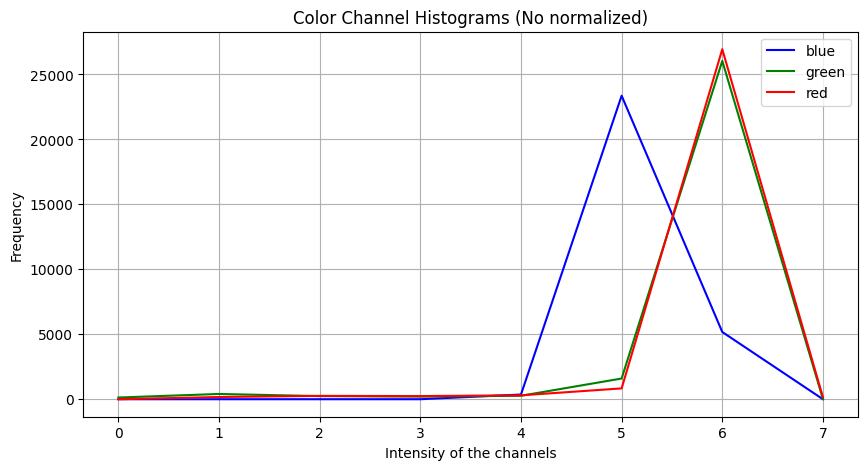

In [ ]:
calc_hist('Normal_Sperm (1).bmp', save_path='Sperm_histogram')

# taking an image as sample we can see the intensity of each channel, this image look different to the ones in the presentation cuz it is bined in 8 and in the slides is in 255 to make it more easy to understand


In [13]:
# 2. Process all images
def process_dataset(root_dir):
    classes = ['Normal_Sperm', 'Abnormal_Sperm', 'Non-Sperm']
    features = []
    labels = []
    
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.exists(class_dir):
            continue
            
        for img_file in os.listdir(class_dir):
            if img_file.lower().endswith(('.png', '.jpg', '.bmp')):
                img_path = os.path.join(class_dir, img_file)
                try:
                    feats = extract_features(img_path)
                    features.append(feats)
                    labels.append(class_idx)
                except Exception as e:
                    print(f"Error processing {img_path}: {str(e)}")
    
    features_df = pd.DataFrame(features)
    labels_df = pd.DataFrame(labels, columns=["Labels"])
    
    return features_df, labels_df

In [ ]:
# 3. Load and prepare data
# We take the process_dataset funtion and applied to the resized folder, I am not including the code that resized the dataset cuz i runned it and didnt save it 
# you can take a sample and see their dimensions is 170 x 170 

print("Processing dataset...")
X, y = process_dataset('data_resized')
print(f"Loaded {len(X)} samples with {len(X.columns)} features")


Processing dataset...
Loaded 3000 samples with 33 features


### From now till the beginning od the advanced classifiers, Ive been workin on the KNN
You will see that to avoid problems with the original Dataframe i stored it in the X_new_features variables and then i started to play with this. 

In [17]:
X_new_features = X 

In [18]:
X_new_features['blue_mean']

0       183.713460
1       182.213149
2       177.159481
3       176.252630
4       179.263529
           ...    
2995    192.897993
2996    182.838374
2997    177.146125
2998    180.540519
2999    174.755260
Name: blue_mean, Length: 3000, dtype: float64

In [19]:
X_new_features.columns

Index(['blue_mean', 'blue_std', 'blue_median', 'blue_hist_0', 'blue_hist_1',
       'blue_hist_2', 'blue_hist_3', 'blue_hist_4', 'blue_hist_5',
       'blue_hist_6', 'blue_hist_7', 'green_mean', 'green_std', 'green_median',
       'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3',
       'green_hist_4', 'green_hist_5', 'green_hist_6', 'green_hist_7',
       'red_mean', 'red_std', 'red_median', 'red_hist_0', 'red_hist_1',
       'red_hist_2', 'red_hist_3', 'red_hist_4', 'red_hist_5', 'red_hist_6',
       'red_hist_7'],
      dtype='object')

### Tried to merge the stats of each channel in a global column and then dropped the used columns so it went from 33 to 36 and then after dropping to 27 

In [20]:
X_new_features['blue_global'] = (X_new_features['blue_mean'] + X_new_features['blue_median'] + X_new_features['blue_std']) / 3
X_new_features['red_global'] = (X_new_features['red_mean'] + X_new_features['red_median'] + X_new_features['red_std']) / 3
X_new_features['green_global'] = (X_new_features['green_mean'] + X_new_features['green_median'] + X_new_features['green_std']) / 3


In [21]:
X_new_features

,blue_mean,blue_std,blue_median,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
0,183.713460,7.206447,186.0,0.0,0.0,0.0,1.0,693.0,27648.0,558.0,...,337.0,263.0,260.0,608.0,2123.0,25309.0,0.0,125.639969,139.047498,133.817629
1,182.213149,5.338925,183.0,0.0,0.0,0.0,0.0,279.0,28360.0,261.0,...,157.0,275.0,300.0,478.0,2934.0,24749.0,5.0,123.517358,136.569217,131.426658
2,177.159481,5.190762,178.0,0.0,0.0,0.0,0.0,590.0,28228.0,82.0,...,171.0,303.0,285.0,466.0,2447.0,25205.0,0.0,120.116748,135.325783,130.633593
3,176.252630,5.892446,177.0,0.0,0.0,0.0,7.0,815.0,28061.0,17.0,...,206.0,347.0,437.0,971.0,6213.0,20669.0,20.0,119.715025,134.985220,126.843311
4,179.263529,5.638385,180.0,0.0,0.0,0.0,0.0,592.0,28205.0,103.0,...,205.0,238.0,285.0,528.0,6790.0,20776.0,0.0,121.633971,134.218584,131.411033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,192.897993,8.089506,195.0,0.0,0.0,0.0,0.0,26.0,8324.0,20550.0,...,0.0,0.0,34.0,694.0,3182.0,24796.0,194.0,131.995833,145.059745,144.166303
2996,182.838374,12.358646,186.0,0.0,0.0,0.0,2.0,1287.0,19002.0,8609.0,...,313.0,823.0,1402.0,2562.0,6564.0,17083.0,152.0,127.065673,140.000196,134.171353
2997,177.146125,7.898083,179.0,0.0,0.0,0.0,15.0,1513.0,27363.0,9.0,...,13.0,223.0,518.0,993.0,2804.0,24349.0,0.0,121.348069,135.834253,130.740400
2998,180.540519,10.479318,183.0,0.0,0.0,0.0,321.0,989.0,27458.0,132.0,...,434.0,244.0,195.0,287.0,3012.0,24310.0,0.0,124.673279,138.387066,134.874258


In [22]:
X_new_features.drop(['blue_mean', 'blue_median', 'blue_std'], axis=1, inplace=True)
X_new_features.drop(['red_mean', 'red_median', 'red_std'], axis=1, inplace=True)
X_new_features.drop(['green_mean', 'green_median', 'green_std'], axis=1, inplace=True)



In [23]:
X_new_features.columns

Index(['blue_hist_0', 'blue_hist_1', 'blue_hist_2', 'blue_hist_3',
       'blue_hist_4', 'blue_hist_5', 'blue_hist_6', 'blue_hist_7',
       'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3',
       'green_hist_4', 'green_hist_5', 'green_hist_6', 'green_hist_7',
       'red_hist_0', 'red_hist_1', 'red_hist_2', 'red_hist_3', 'red_hist_4',
       'red_hist_5', 'red_hist_6', 'red_hist_7', 'blue_global', 'red_global',
       'green_global'],
      dtype='object')

In [24]:
X_new_features.shape

(3000, 27)

In [25]:
y.sample(n=9)

,Labels
1962,1
1976,1
2909,2
2913,2
2599,2
1873,1
1143,1
1021,1
1938,1


## This transformation of the data was used as well, i found it already in the notebook, didnt touch it 

In [42]:
def plot_distribution_before_after(X_before, X_after, feature_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Before scaling
    axes[0].hist(X_before[feature_name], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title(f'Before Scaling: {feature_name}')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')

    # After scaling
    axes[1].hist(X_after[feature_name], bins=30, color='salmon', edgecolor='black')
    axes[1].set_title(f'After Scaling: {feature_name}')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [43]:
X.dtypes.value_counts()

float32    24
float64     3
Name: count, dtype: int64

In [ ]:
# to use again the original dataframe ( 33 columns ) just replace X_new_features for X 

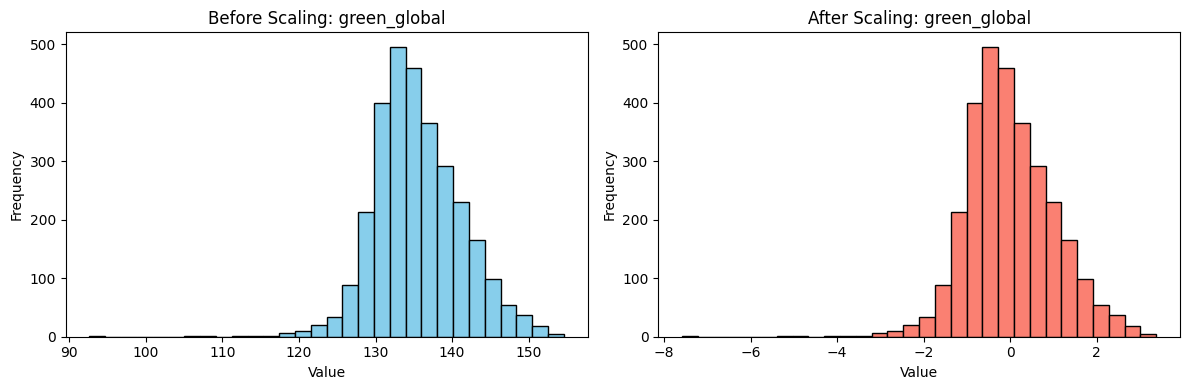

In [44]:
X_new_features.columns = X_new_features.columns.astype(str)

X_numeric = X_new_features.select_dtypes(include=['number'])

# Scale the numeric features
scaler = StandardScaler()
X_after_array = scaler.fit_transform(X_numeric)

# Convert scaled data back to DataFrame
X_after = pd.DataFrame(X_after_array, columns=X_numeric.columns)

feature_name = X_numeric.columns[26]  # or any index
plot_distribution_before_after(X_numeric, X_after, feature_name)

In [45]:
X_after.head()

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
0,-0.146375,-0.180844,-0.239294,-0.397252,-0.273534,0.637351,-0.582594,-0.141241,-0.284407,-0.013701,...,0.255987,-0.235077,-0.496686,-0.303811,-0.339780,0.459726,-0.311712,-0.022780,-0.335813,-0.299681
1,-0.146375,-0.180844,-0.239294,-0.401904,-0.853663,0.734015,-0.623345,-0.141241,-0.431410,-0.053503,...,-0.461850,-0.176752,-0.367586,-0.486504,-0.034681,0.296981,-0.302345,-0.492209,-0.882665,-0.722823
2,-0.146375,-0.180844,-0.239294,-0.401904,-0.417866,0.716094,-0.647906,-0.141241,-0.405897,-0.096623,...,-0.406018,-0.040661,-0.415998,-0.503368,-0.217891,0.429502,-0.311712,-1.244274,-1.157039,-0.863176
3,-0.146375,-0.180844,-0.239294,-0.369345,-0.102578,0.693421,-0.656825,-0.141241,-0.350011,0.152143,...,-0.266439,0.173198,0.074580,0.206323,1.198884,-0.888731,-0.274245,-1.333117,-1.232187,-1.533960
4,-0.146375,-0.180844,-0.239294,-0.401904,-0.415063,0.712971,-0.645025,-0.141241,-0.343937,-0.000433,...,-0.270427,-0.356588,-0.415998,-0.416237,1.415952,-0.857635,-0.311712,-0.908731,-1.401351,-0.725588


In [47]:
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

X_train, X_test, y_train, y_test = train_test_split(X_after, y.values.ravel(), test_size=0.2, stratify=y, random_state=42)


In [48]:
X_test

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
2076,-0.146375,-0.180844,-0.239294,0.091135,-0.995192,0.760896,-0.651199,-0.141241,-0.220017,-0.776581,...,-0.956360,-1.284927,-0.619330,-0.420453,-0.239711,0.551561,-0.201184,-0.798590,-0.632742,-0.722714
2997,-0.146375,-0.180844,-0.239294,-0.332134,0.875515,0.598659,-0.657923,-0.141241,-0.352441,-0.146376,...,-1.036119,-0.429494,0.336006,0.237241,-0.083587,0.180735,-0.311712,-0.971960,-1.044841,-0.844274
1823,-0.146375,-0.180844,-0.239294,-0.401904,-0.231495,0.219336,-0.164101,-0.141241,0.013245,0.089122,...,-0.110907,0.571752,-0.309491,-0.709951,-0.274321,0.410612,-0.154350,0.247442,-0.081909,0.611977
690,-0.146375,-0.180844,-0.239294,-0.401904,0.222519,0.649706,-0.643515,-0.141241,-0.425335,0.085805,...,-0.258463,-0.453796,-0.390179,-0.256030,0.376131,-0.070938,-0.311712,-1.190775,-1.289318,-1.310336
2988,-0.146375,-0.180844,-0.239294,-0.206549,0.909146,0.513128,-0.579438,0.087252,-0.431410,-1.008762,...,-1.075999,-0.585027,-0.015790,1.194269,0.883251,-0.720174,-0.311712,-0.035437,-1.217475,-0.230455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1574,-0.146375,-0.180844,-0.239294,-0.187944,0.268761,0.614271,-0.618543,-0.141241,0.412948,-0.066771,...,0.802341,0.882819,-0.148117,-0.593309,-0.705072,0.636711,-0.139363,-0.802456,0.361324,0.516581
2359,-0.146375,-0.180844,-0.239294,-0.401904,-0.074552,0.519644,-0.482979,-0.141241,-0.432625,-0.892672,...,-1.079987,-0.808606,0.487698,1.866016,1.234999,-1.162491,-0.311712,-0.127539,-0.527043,0.030258
2044,-0.146375,-0.180844,-0.239294,0.030668,3.629028,0.087238,-0.421371,-0.141241,0.774990,1.840430,...,-0.178703,2.992239,2.230542,2.092274,1.534832,-1.929717,-0.060682,-0.391771,-0.163709,-1.089949
2151,-0.146375,-0.180844,-0.170896,0.067878,2.493992,-0.249319,0.027720,-0.141241,-0.363375,0.891805,...,-0.912492,0.139175,3.573177,3.364097,1.586371,-2.161919,0.149134,-0.053628,-0.221461,-1.548202


In [49]:
X_train.head()

,blue_hist_0,blue_hist_1,blue_hist_2,blue_hist_3,blue_hist_4,blue_hist_5,blue_hist_6,blue_hist_7,green_hist_0,green_hist_1,...,red_hist_1,red_hist_2,red_hist_3,red_hist_4,red_hist_5,red_hist_6,red_hist_7,blue_global,red_global,green_global
2945,-0.146375,-0.180844,-0.239294,-0.401904,-1.096085,-0.823054,0.974063,-0.141241,-0.437484,-1.430005,...,-1.087963,-1.513367,-1.113136,0.601221,1.813597,-1.166560,-0.276118,0.593021,-0.345688,-0.917640
92,-0.146375,-0.180844,-0.239294,-0.401904,-0.506146,-1.789281,1.892827,-0.141241,-0.200578,-0.242565,...,0.100456,-0.546144,-0.767795,-0.809729,-0.822823,0.918608,0.156628,0.944241,1.647882,0.809780
827,-0.146375,-0.180844,-0.239294,-0.364693,0.721374,0.580738,-0.623757,-0.141241,-0.261323,1.409237,...,-1.072011,0.853656,-0.144889,0.204918,-0.367619,0.352198,-0.158096,-0.511693,-0.446998,-0.094081
2675,-0.146375,-0.180844,-0.239294,-0.401904,-0.447292,0.728720,-0.657785,-0.141241,-0.437484,-1.430005,...,-1.087963,-1.513367,-1.206733,0.234430,-0.054996,0.366729,-0.311712,-0.515371,-1.315542,-0.331951
2995,-0.146375,-0.180844,-0.239294,-0.401904,-1.208187,-1.986138,2.160526,-0.141241,-0.437484,-1.430005,...,-1.087963,-1.513367,-1.226098,-0.182953,0.058617,0.310640,0.051720,1.382857,0.990838,1.531774


In [ ]:
# 5. Base Classifier (KNN)
print("\n=== Base Classifier (KNN) ===")
knn = KNeighborsClassifier()  # it is using k = 5 by default !
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) ===
              precision    recall  f1-score   support

      Normal       0.55      0.69      0.61       204
    Abnormal       0.52      0.45      0.48       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.63       600
weighted avg       0.64      0.62      0.62       600



In [51]:
from sklearn.feature_selection import SequentialFeatureSelector

###  n_features_to_select perfom well with 29, gives acuraccy of  0.66 % and the precision of each class is increased 

=== Base Classifier (KNN)  without feature selection ===
              precision    recall  f1-score   support

      Normal       0.55      0.69      0.61       204
    Abnormal       0.52      0.45      0.48       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.63       600
weighted avg       0.64      0.62      0.62       600


=== Base Classifier (KNN) - using 29  features and having sequential forward=== this part is extracted from the code bellow !! 
Please check the notes.




              precision    recall  f1-score   support

      Normal       0.60      0.69      0.64       204
    Abnormal       0.57      0.55      0.56       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.66       600
   macro avg       0.67      0.66      0.66       600
weighted avg       0.67      0.66      0.66       600

 

 NOTE: 
 
 THE CODE BELLOW IS USING n_import_feat_knn = 19  and use the   dataframe which had 27 features
AGAIN, Currently it is using the dataframe that has 27 features  it is just for experimntation. 


If you want to see the output that has accuracu 0.66 u must use the original dataframe (33 features) and set n_import_feat_knn = 29 
 

In [53]:

my_direction = 'forward'
n_import_feat_knn = 19 

sfs = SequentialFeatureSelector(knn, n_features_to_select=n_import_feat_knn, direction=my_direction, scoring='accuracy', cv=5, n_jobs=-1) #accuracy as scoring since we have a balanced dataset
sfs.fit(X_train, y_train)

SequentialFeatureSelector(estimator=KNeighborsClassifier(),
                          n_features_to_select=19, n_jobs=-1,
                          scoring='accuracy')

In [54]:
selected_features = sfs.get_support()
selected_features



array([ True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True, False, False,  True,  True,  True,
        True,  True,  True, False, False,  True, False,  True, False])

In [55]:
selected_feature_names = X_train.columns[selected_features]

print("Features seleccionadas:", list(selected_feature_names))

Features seleccionadas: ['blue_hist_0', 'blue_hist_1', 'blue_hist_2', 'blue_hist_3', 'blue_hist_4', 'blue_hist_7', 'green_hist_0', 'green_hist_1', 'green_hist_2', 'green_hist_3', 'green_hist_4', 'green_hist_7', 'red_hist_0', 'red_hist_1', 'red_hist_2', 'red_hist_3', 'red_hist_4', 'red_hist_7', 'red_global']


In [56]:
print(f"\n=== Base Classifier (KNN) - using {n_import_feat_knn}  features and having sequential {my_direction}===")
knn = KNeighborsClassifier()  # it is using k = 5 by default 
knn.fit(X_train[selected_feature_names], y_train)
y_pred = knn.predict(X_test[selected_feature_names])
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal', 'Non-Sperm']))


=== Base Classifier (KNN) - using 19  features and having sequential forward===
              precision    recall  f1-score   support

      Normal       0.59      0.68      0.63       204
    Abnormal       0.58      0.57      0.57       201
   Non-Sperm       0.87      0.74      0.80       195

    accuracy                           0.66       600
   macro avg       0.68      0.66      0.67       600
weighted avg       0.68      0.66      0.67       600



## In Conclusion i got those results 

-- When we use the 33 features, no feature engineering, not best feature selection ( the one we have been using by now we got this following report):

=== Base Classifier (KNN)  without feature selection ===
              precision    recall  f1-score   support

      Normal       0.55      0.69      0.61       204
    Abnormal       0.52      0.45      0.48       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.62       600
   macro avg       0.64      0.62      0.63       600
weighted avg       0.64      0.62      0.62       600





When we apply feature selection , sequential forward.... n_features = 29 we got this report: 




              precision    recall  f1-score   support

      Normal       0.60      0.69      0.64       204
    Abnormal       0.57      0.55      0.56       201
   Non-Sperm       0.85      0.73      0.78       195

    accuracy                           0.66       600
   macro avg       0.67      0.66      0.66       600
weighted avg       0.67      0.66      0.66       600





when we apply feature engineering (27 features) + sequential forward n_feature = 19 
we got this report



 === Base Classifier (KNN) - using 19  features and having sequential forward===
              precision    recall  f1-score   support

      Normal       0.59      0.68      0.63       204
    Abnormal       0.58      0.57      0.57       201
   Non-Sperm       0.87      0.74      0.80       195

    accuracy                           0.66       600
   macro avg       0.68      0.66      0.67       600
weighted avg       0.68      0.66      0.67       600

In [59]:
# 6. Advanced Classifiers with Hyperparameter Tuning

## Random Forest
print("\n=== Random Forest (Optimized) ===")
rf_params = {
    'n_estimators': [100, 150, 250, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Best params: {rf.best_params_}")
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))



=== Random Forest (Optimized) ===


Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 150}
              precision    recall  f1-score   support

           0       0.65      0.61      0.63       204
           1       0.59      0.65      0.62       201
           2       0.83      0.81      0.82       195

    accuracy                           0.69       600
   macro avg       0.69      0.69      0.69       600
weighted avg       0.69      0.69      0.69       600



In [60]:
rf.best_score_

0.69375

In [61]:
report = pd.DataFrame(rf.cv_results_)
report[['param_n_estimators','mean_test_score']]

,param_n_estimators,mean_test_score
0,100,0.682083
1,150,0.691250
2,250,0.691250
3,300,0.681667
4,100,0.685000
5,150,0.687500
6,250,0.677083
7,300,0.682917
8,100,0.674583
9,150,0.672500


In [ ]:
## SVM
print("\n=== SVM (Optimized) ===")
svm_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Test the C with exponential steps , we will choose the proper C below
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear' ]
}
svm = GridSearchCV(SVC(), svm_params, cv=3, n_jobs=-1)
svm.fit(X_train, y_train)
print(f"Best params: {svm.best_params_}")
y_pred_svm = svm.predict(X_test)                                        
print(classification_report(y_test, y_pred_svm))


=== SVM (Optimized) ===


In [ ]:
# 7. Visualization
def plot_results(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal', 'Non-Sperm'],
                yticklabels=['Normal', 'Abnormal', 'Non-Sperm'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


In [ ]:
plot_results(y_test, y_pred, "KNN Base Classifier")
plot_results(y_test, y_pred_rf, "Optimized Random Forest")
plot_results(y_test, y_pred_svm, "Optimized SVM")

NameError: name 'plot_results' is not defined

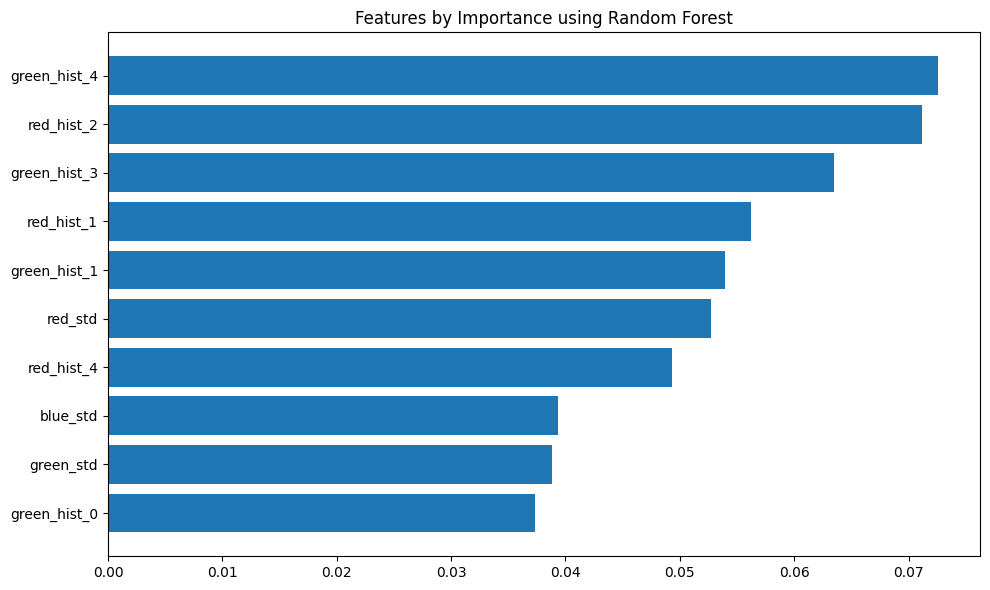

In [ ]:
# 8. Feature Importance Analysis
plt.figure(figsize=(10, 6))
importances = rf.best_estimator_.feature_importances_
sorted_idx = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title("Features by Importance using Random Forest")
plt.tight_layout()
plt.show()